                                                      Stacking (FNN + XGBoost) without redshift  

In [33]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns



df = pd.read_csv(r"C:\Users\PIYUSH\Downloads\StarGalaxyQuaser1_TwinkleKashyap.csv")


df.drop(['objid', 'redshift'], axis=1, inplace=True)   

# Feature engineering
df['u-g'] = df['u'] - df['g']
df['g-r'] = df['g'] - df['r']
df['r-i'] = df['r'] - df['i']
df['i-z'] = df['i'] - df['z']

# Data Cleaning
df = df[(df['u-g'] > -5) & (df['u-g'] < 5) &
        (df['g-r'] > -5) & (df['g-r'] < 5)]


In [34]:
import os
import random
import numpy as np
import tensorflow as tf

random.seed(42)


np.random.seed(42)


tf.random.set_seed(42)


os.environ['PYTHONHASHSEED'] = '42'

In [35]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['class'] = le.fit_transform(df['class'])

In [36]:
X = df.drop('class', axis=1).values
y = df['class'].values

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [39]:
from sklearn.model_selection import KFold
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_class_weight
from tensorflow import keras
from tensorflow.keras import layers

kf = KFold(n_splits=5, shuffle=True, random_state=42)

n_classes = 3

oof_xgb = np.zeros((X_train.shape[0], n_classes))
oof_fnn = np.zeros((X_train.shape[0], n_classes))

test_xgb = np.zeros((X_test.shape[0], n_classes))
test_fnn = np.zeros((X_test.shape[0], n_classes))

In [40]:
for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
    print(f"\nFold {fold+1}")

    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    y_tr, y_val = Y_train[train_idx], Y_train[val_idx]

    X_tr_scaled, X_val_scaled = X_train_scaled[train_idx], X_train_scaled[val_idx]

    # XGBOOST
    xgb = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        objective='multi:softprob',
        num_class=3,
        eval_metric='mlogloss'
    )

    xgb.fit(X_tr, y_tr)

    oof_xgb[val_idx] = xgb.predict_proba(X_val)
    test_xgb += xgb.predict_proba(X_test) / 5

    #FNN
    model = keras.Sequential([
        keras.Input(shape=(X_tr_scaled.shape[1],)),   
        layers.Dense(64, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(3, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Class weights
    classes = np.unique(y_tr)
    weights = compute_class_weight('balanced', classes=classes, y=y_tr)
    class_weights = dict(zip(classes, weights))

    model.fit(
        X_tr_scaled, y_tr,
        epochs=40,              
        batch_size=64,
        verbose=0,
        class_weight=class_weights
    )

    oof_fnn[val_idx] = model.predict(X_val_scaled)
    test_fnn += model.predict(X_test_scaled) / 5


Fold 1
433/433 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step
928/928 ━━━━━━━━━━━━━━━━━━━━ 1s 768us/step

Fold 2
433/433 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
928/928 ━━━━━━━━━━━━━━━━━━━━ 1s 788us/step

Fold 3
433/433 ━━━━━━━━━━━━━━━━━━━━ 0s 841us/step
928/928 ━━━━━━━━━━━━━━━━━━━━ 1s 750us/step

Fold 4
433/433 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step
928/928 ━━━━━━━━━━━━━━━━━━━━ 1s 757us/step

Fold 5
433/433 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step
928/928 ━━━━━━━━━━━━━━━━━━━━ 1s 759us/step


In [41]:
from sklearn.linear_model import LogisticRegression

meta_X_train = np.hstack([oof_xgb, oof_fnn])
meta_X_test = np.hstack([test_xgb, test_fnn])

meta_model = LogisticRegression(max_iter=1000)
meta_model.fit(meta_X_train, Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [42]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

final_pred = meta_model.predict(meta_X_test)

print("K-Fold Stacking Accuracy:", accuracy_score(Y_test, final_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, final_pred))

print("\nClassification Report:")
print(classification_report(Y_test, final_pred))

K-Fold Stacking Accuracy: 0.934115188892259

Confusion Matrix:
[[17081   104   393]
 [  136  2319   311]
 [  694   317  8318]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96     17578
           1       0.85      0.84      0.84      2766
           2       0.92      0.89      0.91      9329

    accuracy                           0.93     29673
   macro avg       0.91      0.90      0.90     29673
weighted avg       0.93      0.93      0.93     29673



In [43]:
def plot_conf_matrix(y_true, final_pred , title):
    cm = confusion_matrix(y_true, final_pred )
    
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='PuRd',linewidths=0.5, linecolor='black')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

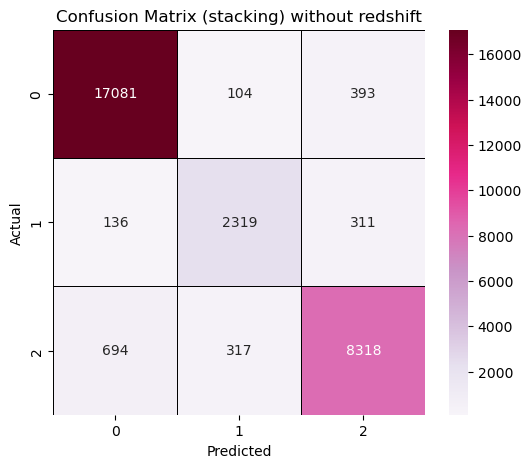

In [44]:
plot_conf_matrix(Y_test,final_pred , "Confusion Matrix (stacking) without redshift")

In [45]:
from sklearn.metrics import accuracy_score

# XGB only
pred_xgb = np.argmax(test_xgb, axis=1)
print("XGB Accuracy:", accuracy_score(Y_test, pred_xgb))

# FNN only
pred_fnn = np.argmax(test_fnn, axis=1)
print("FNN Accuracy:", accuracy_score(Y_test, pred_fnn))

# Stacking
pred_stack = final_pred
print("Stacking Accuracy:", accuracy_score(Y_test, final_pred))

XGB Accuracy: 0.9322616520068749
FNN Accuracy: 0.9255552185488491
Stacking Accuracy: 0.934115188892259


In [46]:
acc_xgb = accuracy_score(Y_test, pred_xgb)
acc_fnn = accuracy_score(Y_test, pred_fnn)
acc_stack = accuracy_score(Y_test, pred_stack)


In [48]:
pred_xgb = np.argmax(test_xgb, axis=1)
pred_fnn = np.argmax(test_fnn, axis=1)

agree = (pred_xgb == pred_fnn)
disagree = (pred_xgb != pred_fnn)

print("Agreement %:", agree.mean())

# Accuracy when models agree
acc_agree = (final_pred[agree] == Y_test[agree]).mean()

# Accuracy when models disagree
acc_disagree = (final_pred[disagree] == Y_test[disagree]).mean()

print("Accuracy (agree):", acc_agree)
print("Accuracy (disagree):", acc_disagree)

Agreement %: 0.9568294409058741
Accuracy (agree): 0.9495632572555649
Accuracy (disagree): 0.5917252146760343


In [49]:
probs = meta_model.predict_proba(meta_X_test)
confidence = probs.max(axis=1)
high_conf = (confidence > 0.9).sum()
print("High confidence samples:", high_conf)

High confidence samples: 25697
